# Segmentation d'images avec Keras

In [1]:
import math
import random

import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas
import tensorflow as tf
from tensorflow import keras
from tifffile import imread

In [2]:
!nvidia-smi

Fri Nov 18 07:11:04 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   45C    P8     9W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [3]:
%%time
!rm -rf sample_data
!git clone https://github.com/mlambda/ign-FNF-2009.git

Cloning into 'ign-FNF-2009'...
remote: Enumerating objects: 4604, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4604 (delta 4), reused 8 (delta 2), pack-reused 4594
Receiving objects: 100% (4604/4604), 3.93 GiB | 34.96 MiB/s, done.
Resolving deltas: 100% (2894/2894), done.
Checking out files: 100% (4869/4869), done.
CPU times: user 1.51 s, sys: 227 ms, total: 1.74 s
Wall time: 3min 4s


## Chargement des données

Les données sont constituées de 20 grandes tuiles cartographiques de l'IGN. Chaque grande tuile est elle-même un carré de 3 × 3 tuiles de 1024 × 1024 pixels.

2 tuiles ont été mises de côté pour la validation, et 2 autres tuiles pour le test.

In [4]:
df_train = pandas.read_csv("ign-FNF-2009/train-files.csv")
df_val = pandas.read_csv("ign-FNF-2009/val-files.csv")
df_test = pandas.read_csv("ign-FNF-2009/test-files.csv")

print("Coordonnées en entraînement")
print(df_train.coord.unique())

print("Coordonnées en val")
print(df_val.coord.unique())

print("Coordonnées en test")
print(df_test.coord.unique())

df_test

Coordonnées en entraînement
['945_6845' '980_6825' '945_6925' '955_6915' '915_6825' '975_6850'
 '940_6905' '995_6895' '940_6925' '915_6890' '1015_6895' '920_6860'
 '890_6940' '975_6835' '975_6825' '925_6860']
Coordonnées en val
['970_6845' '910_6935']
Coordonnées en test
['915_6915' '995_6850']


,Unnamed: 0,Observations,Annotations,latitude,longitude,ligne,colonne,coord
0,0,ign-FNF-2009/test/observations/915_6915_8_2_ob...,ign-FNF-2009/test/annotations/915_6915_8_2_0M5...,915,6915,8,2,915_6915
1,1,ign-FNF-2009/test/observations/995_6850_5_4_ob...,ign-FNF-2009/test/annotations/995_6850_5_4_0M5...,995,6850,5,4,995_6850
2,2,ign-FNF-2009/test/observations/915_6915_4_9_ob...,ign-FNF-2009/test/annotations/915_6915_4_9_0M5...,915,6915,4,9,915_6915
3,3,ign-FNF-2009/test/observations/915_6915_5_4_ob...,ign-FNF-2009/test/annotations/915_6915_5_4_0M5...,915,6915,5,4,915_6915
4,4,ign-FNF-2009/test/observations/995_6850_8_6_ob...,ign-FNF-2009/test/annotations/995_6850_8_6_0M5...,995,6850,8,6,995_6850
...,...,...,...,...,...,...,...,...
155,155,ign-FNF-2009/test/observations/995_6850_9_1_ob...,ign-FNF-2009/test/annotations/995_6850_9_1_0M5...,995,6850,9,1,995_6850
156,156,ign-FNF-2009/test/observations/995_6850_5_8_ob...,ign-FNF-2009/test/annotations/995_6850_5_8_0M5...,995,6850,5,8,995_6850
157,157,ign-FNF-2009/test/observations/995_6850_3_6_ob...,ign-FNF-2009/test/annotations/995_6850_3_6_0M5...,995,6850,3,6,995_6850
158,158,ign-FNF-2009/test/observations/995_6850_4_4_ob...,ign-FNF-2009/test/annotations/995_6850_4_4_0M5...,995,6850,4,4,995_6850


## Étude d'un exemple et de son annotation

In [5]:
example_input = imread(df_train.Observations[0])
example_annotation = imread(df_train.Annotations[0])

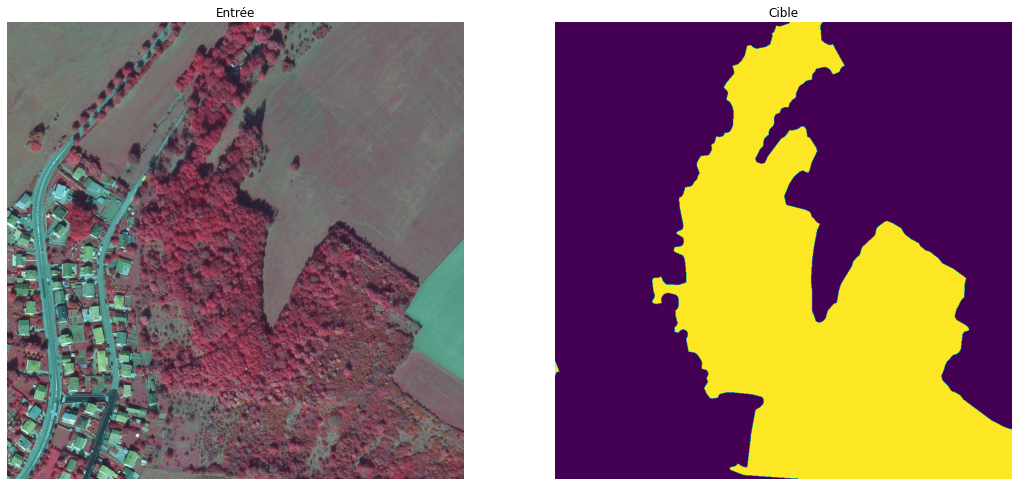

In [6]:
# Hack nécessaire pour que imshow affiche correctement les tuiles avec seulement
# de la (sinon les 1 représentant les pixels de forêt sont remplacés par des 0
# si la tuile est consitutée seulement de 1s).
class NoopNormalize(matplotlib.colors.Normalize):
  def __init__(self, vmin=None, vmax=None, vcenter=None, clip=False):
    self.vmin = vmin
    self.vmax = vmax
    self.vcenter = vcenter
    self.clip = clip

  def __call__(self, value, clip=None):
    return value


_noop_normalize = NoopNormalize()


def display_sample(*images: numpy.array) -> None:
  """Show side-by-side an input image, the ground truth and the prediction."""
  figure, axes = plt.subplots(1, len(images), figsize=(18, 18))

  titles = ["Entrée", "Cible", "Prédiction"]
  for image, ax, title in zip(images, axes, titles):
    ax.set_title(title)
    if image.ndim == 2 or image.shape[2] == 3:
      ax.imshow(image, norm=_noop_normalize)
    elif image.shape[2] == 2:
      ax.imshow(image[..., 1], norm=_noop_normalize)
    elif image.shape[2] == 1:
      ax.imshow(image[..., 0], norm=_noop_normalize)
    ax.axis("off")
  plt.show()


display_sample(example_input, example_annotation)

## Options générales

In [7]:
# Dimension des images originales
dim_original = 1024

# Dimension des images en entrée du réseau
dim_input = 512

# Nombre de canaux des images en entrée
num_channel = 3

## Augmentation des données

En traitement d'images, il est extrêmement important d'augmenter les données par des transformations pour rendre le réseau appris moins sensibles aux rotations, recadrages, etc. Implémentez la fonction `transform_data`, qui, si `eval` vaut `True` se contentera de faire un recadrage centré des images `X` et `Y`, et sinon fera toutes les transformations que vous jugerez opportunes sur ces mêmes tableaux pour l'entraînement (recadrage aléatoire, miroir, rotation, bruitage des couleurs, de la luminosité, etc).

Pour ce faire, utilisez les fonctions du module [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image/).

In [8]:
def transform_data(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  eval: bool = False,
  cropped_size: tuple[int, int] = (dim_input, dim_input),
) -> tuple[numpy.ndarray, numpy.ndarray]:
  # Votre code ici
  return X, Y


# display_sample(*transform_data(example_input, example_annotation))

### Solution

In [9]:
def transform_data(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  eval: bool = False,
  cropped_size: tuple[int, int] = (dim_input, dim_input),
) -> tuple[numpy.ndarray, numpy.ndarray]:
  height, width = X.shape[:2]
  cropped_height, cropped_width = cropped_size
  if eval:
    # Recadrage centré
    crop_params = dict(
      offset_height=(height - cropped_height) // 2,
      offset_width=(width - cropped_width) // 2,
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)
  else:
    # Rotation aléatoire
    k = random.choice([None, 1, 3])
    if k is not None:
      X = tf.image.rot90(X, k)
      Y = tf.image.rot90(Y, k)

    # Recadrage aléatoire
    crop_params = dict(
      offset_height=random.randint(0, height - cropped_height),
      offset_width=random.randint(0, width - cropped_width),
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)

    # Miroir horizontal
    if random.random() > 0.5:
      X = tf.image.flip_left_right(X)
      Y = tf.image.flip_left_right(Y)

    # Miroir vertical
    if random.random() > 0.5:
      X = tf.image.flip_up_down(X)
      Y = tf.image.flip_up_down(Y)
  return X, Y


for _ in range(10):
  display_sample(*transform_data(example_input, example_annotation))

Output hidden; open in https://colab.research.google.com to view.

## Création d'un générateur Keras

Pour définir un générateur Keras, nous allons utiliser la classe [`keras.utils.Sequence`](https://www.tensorflow.org/api_docs/python/tf/keras/utils/Sequence). Pour ce faire, Il faut principalement deux méthodes : `__getitem__`, qui est appelée à chaque itération pour récupérer le batch à traiter, et `__len__`, qui est appelée pour connaître le nombre total de batchs qui sera fourni par le générateur. Nous utiliserons aussi `on_epoch_end` pour mélanger le dataset avant l'itération suivante.

In [10]:
class DataGenerator(keras.utils.Sequence):
  """Generate data in batches with appropriate transforms."""

  def __init__(
    self,
    df: pandas.DataFrame,
    batch_size: int,
    eval: bool,
    cropped_size: tuple[int, int] = (dim_input, dim_input),
  ) -> None:
    """Initialize the generator."""
    # Votre code ici

  def __len__(self):
    """Compute the number of batches per epoch."""
    # Votre code ici

  def __getitem__(self, index):
    """Generate one batch of data."""
    # Votre code ici

  def on_epoch_end(self):
    """Update indexes after each epoch."""
    # Votre code ici

### Solution

In [11]:
class DataGenerator(keras.utils.Sequence):
  """Generate data for Keras."""

  def __init__(
    self,
    df: pandas.DataFrame,
    batch_size: int,
    eval: bool,
    cropped_size: tuple[int, int] = (dim_input, dim_input),
  ) -> None:
    """Initialize the generator."""
    self.X_paths = df.Observations
    self.Y_paths = df.Annotations
    assert self.X_paths.shape[0] == self.Y_paths.shape[0]
    self.batch_size = batch_size
    self.eval = eval
    self.cropped_size = cropped_size
    if eval:
      self.indices = numpy.arange(self.X_paths.shape[0])
    else:
      self.indices = numpy.random.permutation(self.X_paths.shape[0])

  def __len__(self):
    """Compute the number of batches per epoch."""
    return int(math.ceil(self.X_paths.shape[0] / self.batch_size))

  def __getitem__(self, index):
    """Generate one batch of data."""
    # Generate indexes of the batch
    start = index * self.batch_size
    Xs = []
    Ys = []
    for i in self.indices[start : start + self.batch_size]:
      X, Y = transform_data(
        imread(self.X_paths[i]),
        imread(self.Y_paths[i]).argmax(axis=-1)[..., numpy.newaxis],
        self.eval,
        self.cropped_size,
      )
      Xs.append(X)
      Ys.append(tf.squeeze(Y))
    return tf.stack(Xs), tf.stack(Ys)

  def on_epoch_end(self):
    """Update indexes after each epoch."""
    if not self.eval:
      self.indices = numpy.arange(self.X_paths.shape[0])


generator = DataGenerator(df_train, 3, True)
X, Y = generator[0]
X.shape, Y.shape

(TensorShape([3, 512, 512, 3]), TensorShape([3, 512, 512]))

## Création du modèle

Pour le modèle, nous devons passer d'une image de dimension (batch × hauteur × largeur × 3) à une sortie de dimension (batch × hauteur × largeur).

Vous pouvez vous inspirer de l'architecture vue en démonstration des autoencodeurs débruiteurs. Cette fois cependant, on ne réduira pas les capacités du réseau au centre du modèle.

Vous pouvez aussi consulter [cette page d'exemple de code Keras](https://keras.io/examples/vision/oxford_pets_image_segmentation/#prepare-unet-xceptionstyle-model) pour plus d'insipration.

In [12]:
def get_model(
  input_height: int = dim_input, input_width: int = dim_input
) -> keras.Model:
  pass  # Votre code ici

### Solution

In [24]:
# Implémentation du modèle U-net tel que décrit sur la page
# https://paperswithcode.com/method/u-net
# Vous pouvez aussi implémenter tout autre modèle adapté :
# https://paperswithcode.com/methods/category/segmentation-models


def downsample(inputs):
  return keras.layers.MaxPooling2D(pool_size=(2, 2))(inputs)


def upsample(inputs):
  return keras.layers.UpSampling2D(size=(2, 2))(inputs)


def semiblock(inputs, feature_maps):
  conv = keras.layers.Conv2D(feature_maps, 3, activation="relu", padding="same")(inputs)
  batch_norm = keras.layers.BatchNormalization()(conv)
  relu = keras.layers.ReLU()(batch_norm)
  dropout = keras.layers.Dropout(0.1)(relu)
  return dropout


def block(inputs, feature_maps):
  return semiblock(semiblock(inputs, feature_maps), feature_maps)


def concat(*layers):
  return keras.layers.Concatenate()(layers)


def get_model(starting_depth=32, steps=5):
  inputs = keras.layers.Input((dim_input, dim_input, num_channel))
  encodings = []
  depths = [min(512, starting_depth * 2**i) for i in range(steps)]
  for depth in depths:
    encodings.append(block(downsample(encodings[-1]) if encodings else inputs, depth))
  x = encodings[-1]
  for depth, encoding in zip(depths[-2::-1], encodings[-2::-1]):
    print(upsample(x), encoding)
    x = block(concat(encoding, upsample(x)), depth)
  outputs = keras.layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)

  model = keras.Model(inputs=inputs, outputs=outputs)

  return model

## Entraînement

On peut maintenant utiliser notre classe de génération de données pour entraîner notre modèle.

In [14]:
# Votre code ici

### Solution

In [25]:
# Construction du modèle
model = get_model()
model.summary()
model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

batch_size = 4

# Création des générateurs
train_generator = DataGenerator(df_train, batch_size, eval=False)
val_generator = DataGenerator(df_val, batch_size, eval=True)

# Entraînement du modèle, en évaluation sur le générateur de validation à la fin
# de chaque epoch
epochs = 15
model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=epochs,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_model.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

KerasTensor(type_spec=TensorSpec(shape=(None, 64, 64, 512), dtype=tf.float32, name=None), name='up_sampling2d_24/resize/ResizeNearestNeighbor:0', description="created by layer 'up_sampling2d_24'") KerasTensor(type_spec=TensorSpec(shape=(None, 64, 64, 256), dtype=tf.float32, name=None), name='dropout_61/Identity:0', description="created by layer 'dropout_61'")
KerasTensor(type_spec=TensorSpec(shape=(None, 128, 128, 256), dtype=tf.float32, name=None), name='up_sampling2d_26/resize/ResizeNearestNeighbor:0', description="created by layer 'up_sampling2d_26'") KerasTensor(type_spec=TensorSpec(shape=(None, 128, 128, 128), dtype=tf.float32, name=None), name='dropout_59/Identity:0', description="created by layer 'dropout_59'")
KerasTensor(type_spec=TensorSpec(shape=(None, 256, 256, 128), dtype=tf.float32, name=None), name='up_sampling2d_28/resize/ResizeNearestNeighbor:0', description="created by layer 'up_sampling2d_28'") KerasTensor(type_spec=TensorSpec(shape=(None, 256, 256, 64), dtype=tf.flo

KeyboardInterrupt: ignored

## Application aux données de test

Une fois votre modèle suffisamment appris, appliquez-le aux données de test : les prédictions sont-elles de bonne qualité ?

In [ ]:
# Votre code ici

### Solution

In [ ]:
# Chargement du meilleur modèle
model.load_weights("best_model.h5")

test_generator = DataGenerator(df_test, 24, eval=True)
X, Y = test_generator[2]
model.evaluate(test_generator, batch_size=4)
preds = model.predict(X)[..., 0]

print(X.shape, Y.shape, preds.shape)

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)

## Modèle pré-entraîné

In [ ]:
base_model = keras.applications.EfficientNetB7(
  include_top=False,
  weights="imagenet",
  input_shape=(dim_input, dim_input, num_channel),
)

base_model.trainable = False

model = keras.Sequential(
  [  # (16, 16, 2560)
    base_model,
    # Votre code
  ]
)

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

model.summary()

# model.fit(train_generator,
#           validation_data=val_generator,
#           epochs=epochs,
#           callbacks=[keras.callbacks.EarlyStopping(patience=5,
#                                                    monitor="val_loss"),
#                      keras.callbacks.ModelCheckpoint(
#                          filepath="best_model_b7.h5",
#                          monitor="val_accuracy",
#                          mode="max",
#                          save_weights_only=True,
#                          save_best_only=True,)])

### Solution

In [ ]:
base_model = keras.applications.EfficientNetB7(
  include_top=False,
  weights="imagenet",
  input_shape=(dim_input, dim_input, num_channel),
)

base_model.trainable = False

starting_depth = 512

conv_params = dict(kernel_size=3, padding="same", activation="relu")

model = keras.Sequential(
  [  # (16, 16, 2560)
    base_model,
    # (16, 16, 512)
    keras.layers.Conv2D(starting_depth, 1, activation="relu"),
    # (32, 32, 512)
    keras.layers.UpSampling2D(),
    # (32, 32, 256)
    keras.layers.Conv2D(starting_depth // 2, **conv_params),
    # (64, 64, 256)
    keras.layers.UpSampling2D(),
    # (64, 64, 128)
    keras.layers.Conv2D(starting_depth // 4, **conv_params),
    # (128, 128, 128)
    keras.layers.UpSampling2D(),
    # (128, 128, 64)
    keras.layers.Conv2D(starting_depth // 8, **conv_params),
    # (256, 256, 64)
    keras.layers.UpSampling2D(),
    # (256, 256, 32)
    keras.layers.Conv2D(starting_depth // 16, **conv_params),
    # (512, 512, 32)
    keras.layers.UpSampling2D(),
    # (512, 512, 16)
    keras.layers.Conv2D(starting_depth // 32, **conv_params),
    keras.layers.Dropout(0.9),
    # (512, 512, 1)
    keras.layers.Conv2D(1, 3, padding="same", activation="sigmoid"),
  ]
)

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

model.summary()

model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=epochs,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_model_b7.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

In [ ]:
# Chargement du meilleur modèle
model.load_weights("best_model_b7.h5")


test_generator = DataGenerator(df_test, 24, eval=True)
X, Y = test_generator[2]
model.evaluate(test_generator, batch_size=4)
preds = model.predict(X)[..., 0]

print(X.shape, Y.shape, preds.shape)

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)